## Lecture fichier EDF

In [1]:
from pathlib import Path
import mne
from collections import defaultdict

edf_path = Path("../../../../home/darryld/documents/EEG/raw/CD28/CD28_raw.edf")
raw = mne.io.read_raw_edf(edf_path, preload=False)
raw


Extracting EDF parameters from /home/darryld/documents/EEG/raw/CD28/CD28_raw.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_461056/4078908059.py:6: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=False)


<RawEDF | CD28_raw.edf, 33 x 7559680 (29530.0 s), ~37 KiB, data not loaded>

## Renommage des canaux

In [2]:
from collections import defaultdict

print(20*"==")
print("Nom des canaux avant :")
print(set(raw.ch_names))

############### Étape 1 : Renommer + garder les anciens et nouveaux noms #################

# On capture les anciens noms (avant renommage)
old_eeg_names = [c for c in raw.ch_names if c.startswith("EEG ")]

# Renommage : remove "EEG "
rename = {c: c.replace("EEG ", "") for c in old_eeg_names}
raw = raw.rename_channels(rename)

# Nouveaux noms EEG (après renommage)
new_eeg_names = list(rename.values())


print("Anciens noms EEG :", old_eeg_names)

print(20*"==")
print("Nom des canaux après renommage :")
print(set(raw.ch_names))
print("Nouveaux noms EEG :", new_eeg_names)
print(20*"==")

############## Étape 2 : Typage des canaux ##############

channels_by_type = defaultdict(list)

type_map = {
    "Menton": "emg",
    "JAMBG": "emg",
    "JAMBD": "emg",
    "EMG1": "emg",
    "EMG2": "emg",
    "ECG": "ecg",
    "EOGD": "eog",
    "EOGG": "eog",
    "RONF": "misc",
}

for ch in raw.ch_names:

    # 1) Les nouveaux noms EEG sont les EEG
    if ch in new_eeg_names:
        ch_type = "eeg"

    # 2) Sinon, typage manuel
    elif ch in type_map:
        ch_type = type_map[ch]

    # 3) Sinon : misc
    else:
        ch_type = "misc"

    channels_by_type[ch_type].append(ch)

############### Étape 3 : Injection dans MNE #################

mne_type_map = {}
for ch_type, ch_list in channels_by_type.items():
    mapped_type = ch_type  # eeg, eog, emg, ecg, misc
    for ch in ch_list:
        mne_type_map[ch] = mapped_type

raw.set_channel_types(mne_type_map)

print("Types présents :", raw.get_channel_types(unique=True))


Nom des canaux avant :
{'EEG Fp1', 'EOGG', 'NAF2P', 'JAMBG', 'CPAP', 'EEG T4', 'ECG', 'Menton', 'PCO2', 'POS', 'EEG Pz', 'SLI', 'VAB', 'EEG O1', 'EEG C4', 'PTT', 'VTH', 'THERM', 'RONF', 'FC', 'SAT', 'EEG A1', 'EEG T3', 'EOGD', 'EEG C3', 'EEG Fp2', 'Pouls', 'EEG Cz', 'EEG O2', 'EMG2', 'JAMBD', 'EMG1', 'SPo2_Cap'}
Anciens noms EEG : ['EEG Fp1', 'EEG Fp2', 'EEG C3', 'EEG C4', 'EEG T3', 'EEG T4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG Cz', 'EEG Pz']
Nom des canaux après renommage :
{'EOGG', 'NAF2P', 'JAMBG', 'T4', 'Pz', 'A1', 'C3', 'CPAP', 'ECG', 'Menton', 'PCO2', 'POS', 'SLI', 'VAB', 'Fp2', 'PTT', 'VTH', 'THERM', 'RONF', 'Fp1', 'FC', 'O1', 'SAT', 'EOGD', 'C4', 'Cz', 'Pouls', 'T3', 'EMG2', 'O2', 'JAMBD', 'EMG1', 'SPo2_Cap'}
Nouveaux noms EEG : ['Fp1', 'Fp2', 'C3', 'C4', 'T3', 'T4', 'O1', 'O2', 'A1', 'Cz', 'Pz']
Types présents : ['eeg', 'eog', 'emg', 'misc', 'ecg']


/tmp/ipykernel_461056/1905882958.py:68: RuntimeWarning: The unit for channel(s) CPAP, FC, NAF2P, PCO2, POS, PTT, Pouls, RONF, SAT, SLI, SPo2_Cap, THERM, VAB, VTH has changed from V to NA.
  raw.set_channel_types(mne_type_map)


In [3]:
for ch_type, ch_list in channels_by_type.items():
    print(f"{ch_type.upper()} : {len(ch_list)}")
    print(ch_list)
    print()


EEG : 11
['Fp1', 'Fp2', 'C3', 'C4', 'T3', 'T4', 'O1', 'O2', 'A1', 'Cz', 'Pz']

EOG : 2
['EOGD', 'EOGG']

EMG : 5
['Menton', 'JAMBG', 'JAMBD', 'EMG2', 'EMG1']

MISC : 14
['VTH', 'VAB', 'THERM', 'NAF2P', 'RONF', 'SAT', 'POS', 'PTT', 'PCO2', 'FC', 'Pouls', 'SPo2_Cap', 'SLI', 'CPAP']

ECG : 1
['ECG']



## Application montage bipolaire

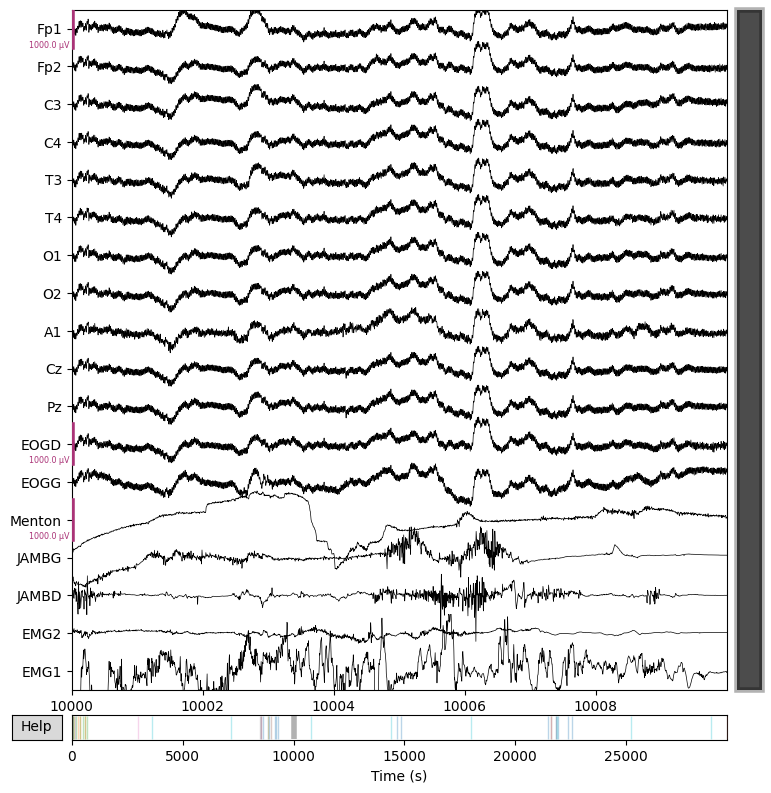

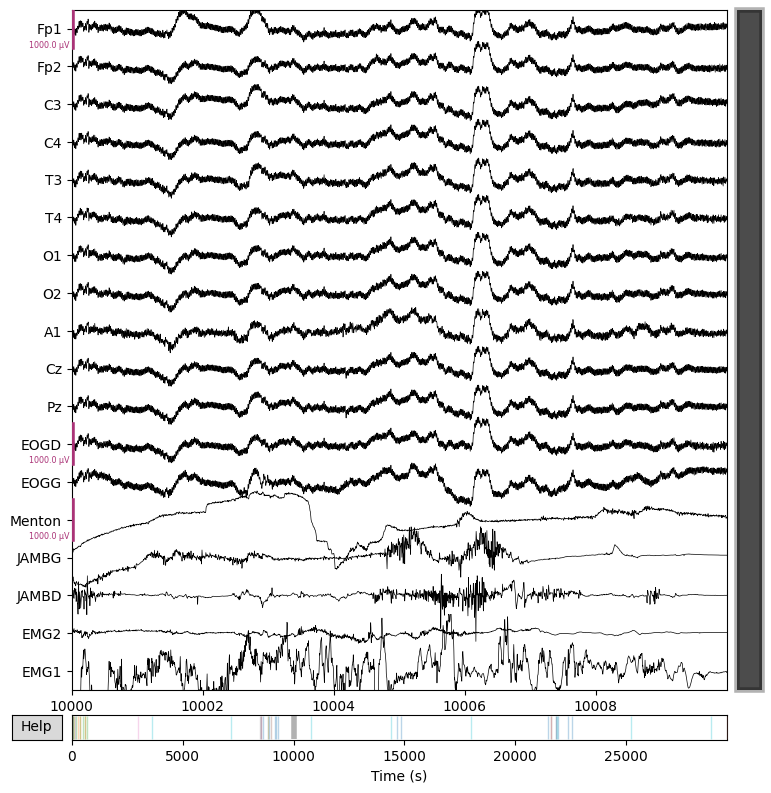

In [16]:
# Montage avant : 
import sys, os
sys.path.append("/home/darryld/Cerco_studies") 

scaling = dict(
    eeg=500e-6,
    eog=500e-6,
    emg=500e-6,
)

picks_names = (
    channels_by_type["eeg"]
    + channels_by_type["emg"]
    + channels_by_type["eog"]
)

raw.plot(start=10000, picks=picks_names, scalings=scaling)


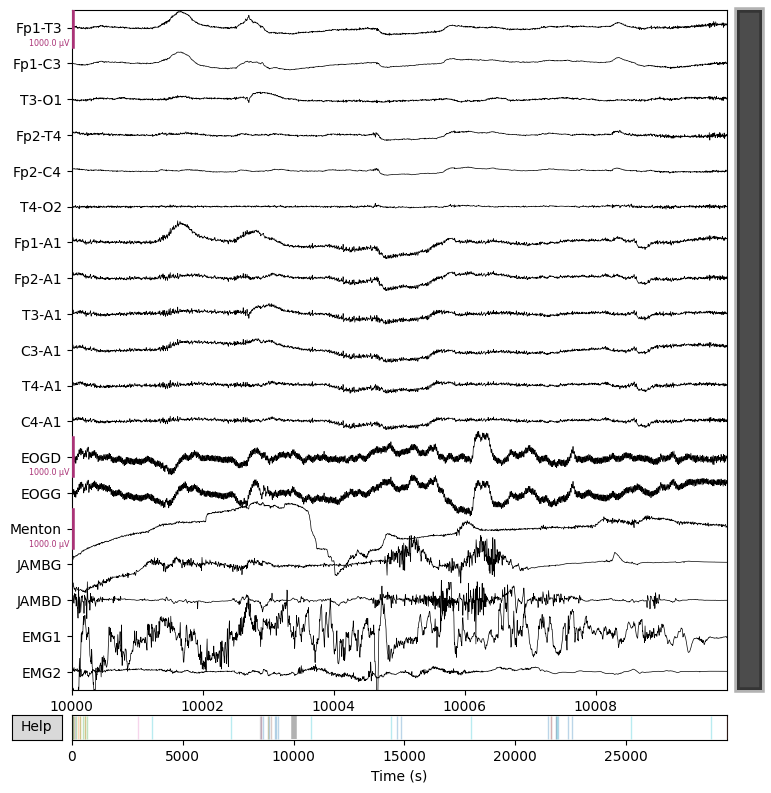

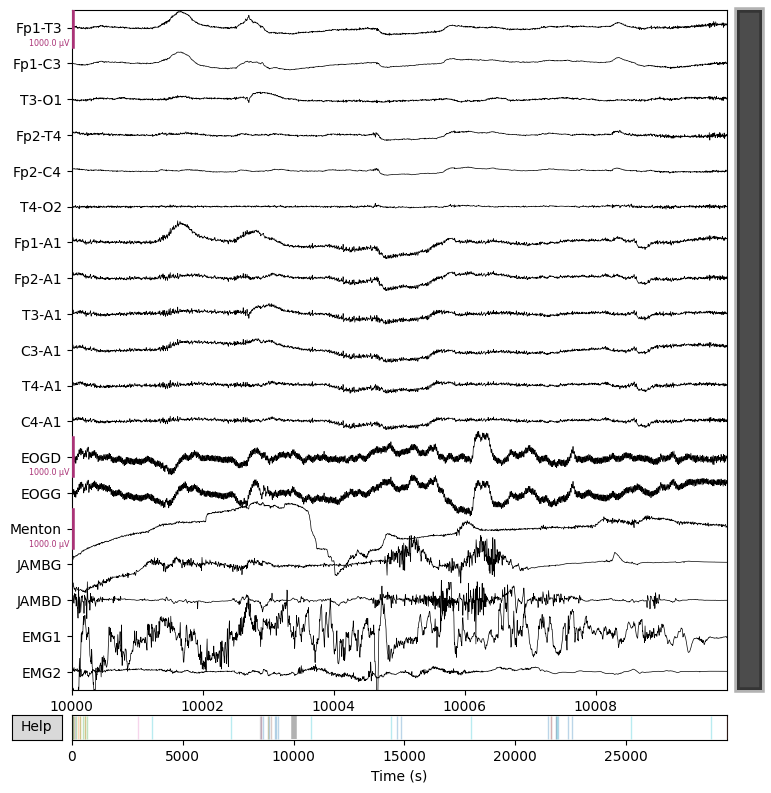

In [19]:
# Montage après :
from src.data.preprocessing import apply_montage_gp2

base_name = edf_path.stem.split("_")[0]

scalings = dict(
    eeg=500e-6,
    eog=500e-6,
    emg=500e-6,
)


# Application du montage GP2
raw_gp2 = apply_montage_gp2(raw, base_name)


# Affichage des signaux
raw_gp2.plot(start=10000, picks=["eeg","emg","eog"], scalings=scalings)


### Filtres sur EEG et EMG

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_461056/904425991.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_gp2.plot_psd(picks="eeg", fmax=100)


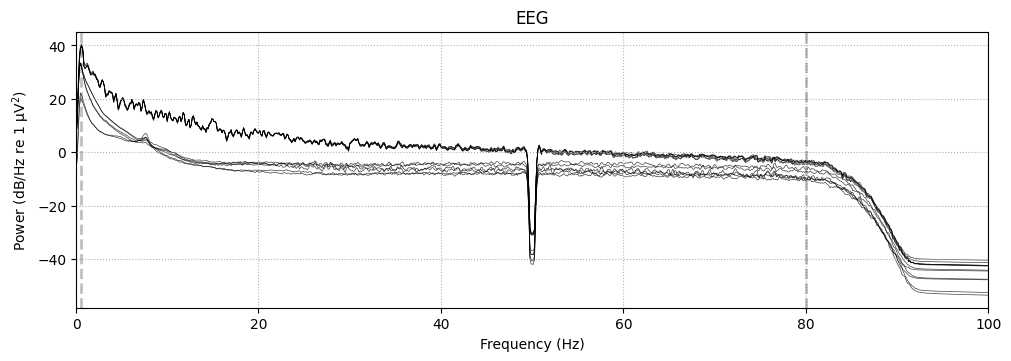

In [24]:
from src.data.preprocessing import filter_eeg, filter_emg
filter_eeg(raw_gp2)
filter_emg(raw_gp2)

raw_gp2.plot_psd(picks="eeg", fmax=100)



Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_461056/1462985321.py:10: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  spec_emg.plot(picks=np.arange(len(emg_names)))


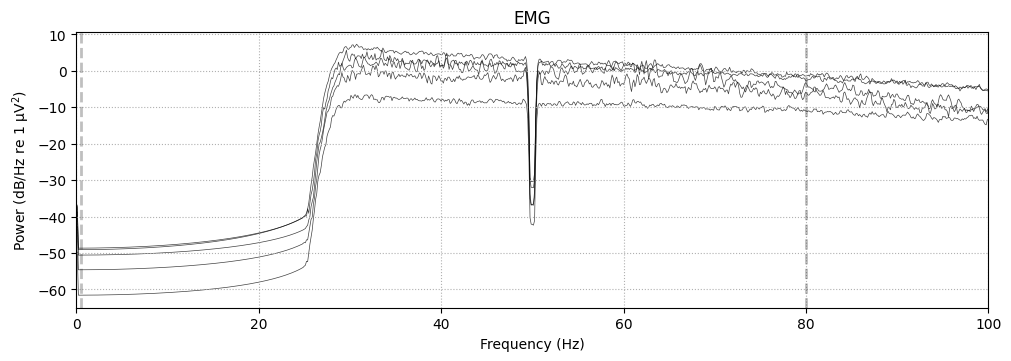

In [ ]:
import numpy as np

emg_names = ['Menton', 'JAMBG', 'JAMBD', 'EMG1', 'EMG2']

spec_emg = raw_gp2.compute_psd(picks=emg_names, fmax=100)

spec_emg.plot(picks=np.arange(len(emg_names)))
